In [15]:
! pip install pyorderbook &> /dev/null

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from enum import Enum
import random
import pyorderbook as ob

In [337]:
TICKS = 200
TRADERS = 1000
MAX_QTY = 100
TICKER = "ABC"
STARTING_PRICE = 100
SPREAD = 0.0001

In [338]:
class Actions(Enum):
  Wait = 0
  Buy = 1
  Sell = 2

actions_list = list(Actions)

In [339]:
def get_best_bid(book, symbol):
    bids = book.levels[symbol]["bid"]
    if bids:
        return float(bids[0].price)
    return None

def get_best_ask(book, symbol):
    asks = book.levels[symbol]["ask"]
    if asks:
        return float(asks[0].price)
    return None


In [352]:
book = ob.Book()

last_price = STARTING_PRICE

ohlc_df = pd.DataFrame(columns=["Open", "High", "Low", "Close", "Volume"])
ob_history = []

book.match(ob.bid(TICKER, STARTING_PRICE * (1 - SPREAD), MAX_QTY))
book.match(ob.ask(TICKER, STARTING_PRICE * (1 + SPREAD), MAX_QTY))

trend_window = 10

for i in range(TICKS):
  tick_ohlc = {}
  tick_ohlc["Open"] = last_price

  high = last_price
  low = last_price

  volume = 0

  trend = 1
  if len(ohlc_df) >= trend_window:
    log_ret = np.log(ohlc_df["Close"] / ohlc_df["Close"].shift(1))
    trend = 1 if log_ret[-trend_window:].mean() > 0 else -1

  for j in range(TRADERS):
    side = random.choice(actions_list)
    if side == Actions.Wait:
      continue

    qty = random.randint(1, MAX_QTY)

    best_bid = get_best_bid(book, TICKER)
    best_ask = get_best_ask(book, TICKER)
    
    trade = None

    if side == Actions.Buy and best_ask is not None:
      price = round(
        best_ask * (1 + random.uniform(-SPREAD, SPREAD) * trend), 2
      )
      trade = book.match(ob.bid(TICKER, price, qty))
    elif side == Actions.Sell and best_bid is not None:
      price = round(
        best_bid * (1 - random.uniform(-SPREAD, SPREAD) * trend), 2
      )
      trade = book.match(ob.ask(TICKER, price, qty))

    if trade and trade.order.status in ("partial_fill", "filled"):
      last_price = trade.average_price
      volume += sum(t.fill_quantity for t in trade.trades)
      high = max(high, last_price)
      low = min(low, last_price)

  ob_history.append({
    "bid": [(b.price, len(b.orders)) for b in book.levels[TICKER][ob.Side.BID]],
    "ask": [(a.price, len(a.orders)) for a in book.levels[TICKER][ob.Side.ASK]]
  })

  tick_ohlc["High"] = high
  tick_ohlc["Low"] = low
  tick_ohlc["Close"] = last_price
  tick_ohlc["Volume"] = volume

  ohlc_df.loc[len(ohlc_df)] = tick_ohlc

ob_history = pd.Series(ob_history)

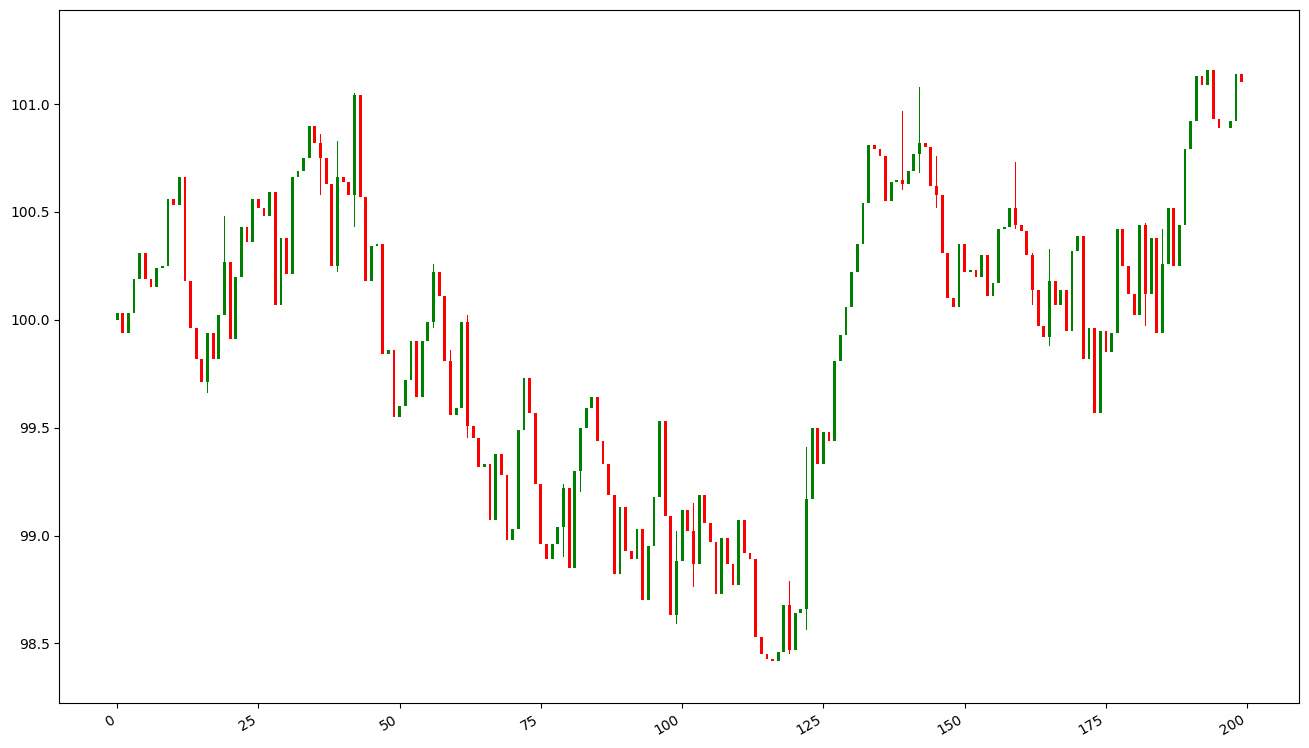

In [353]:
fig, ax = plt.subplots(figsize=(16, 9))
# fig, ax = plt.subplots()

up = ohlc_df[ohlc_df["Close"] >= ohlc_df["Open"]]
down = ohlc_df[ohlc_df["Close"] < ohlc_df["Open"]]

col1 = 'green'
col2 = 'red'

width = .5
width2 = .02

plt.bar(up.index, up.Close-up.Open, width, bottom=up.Open, color=col1)
plt.bar(up.index, up.High-up.Close, width2, bottom=up.Close, color=col1)
plt.bar(up.index, up.Low-up.Open, width2, bottom=up.Open, color=col1)

plt.bar(down.index, down.Close-down.Open, width, bottom=down.Open, color=col2)
plt.bar(down.index, down.High-down.Open, width2, bottom=down.Open, color=col2)
plt.bar(down.index, down.Low-down.Close, width2, bottom=down.Close, color=col2)

plt.xticks(rotation=30, ha='right')

plt.show()


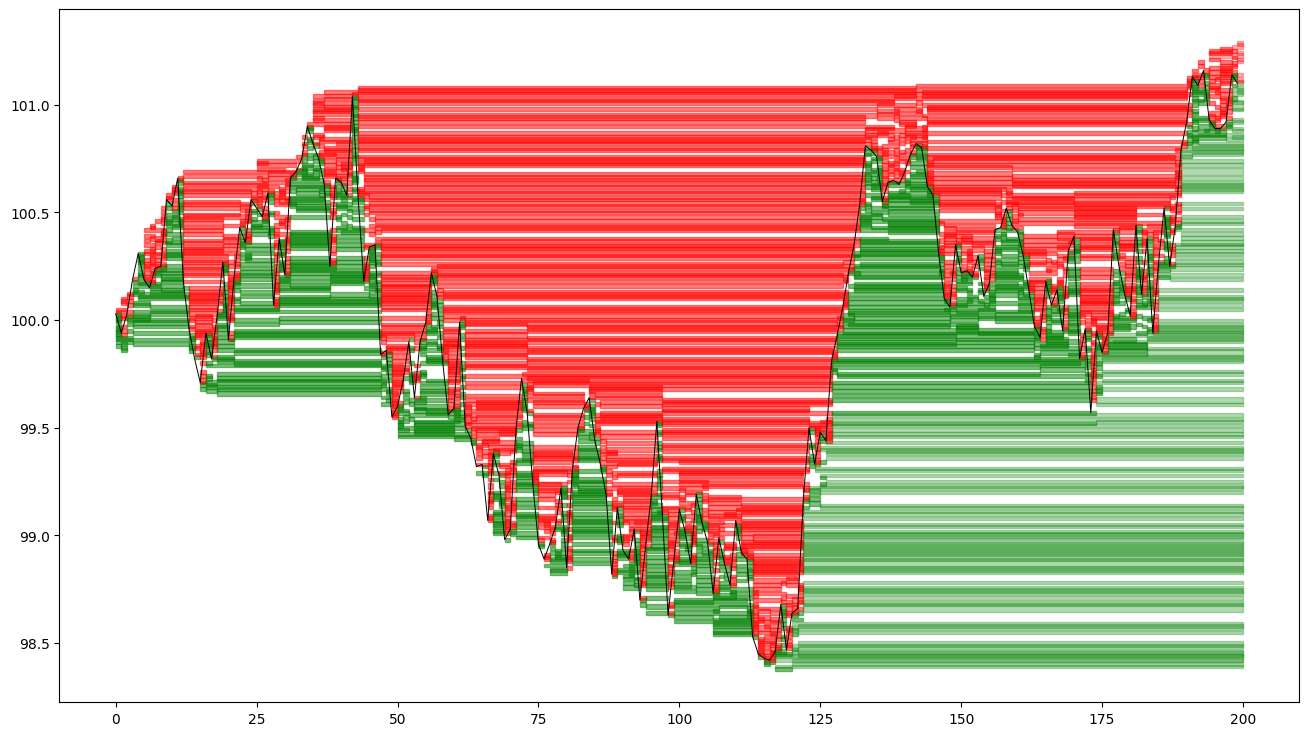

In [354]:
fig, ax = plt.subplots(figsize=(16, 9))
# fig, ax = plt.subplots()

plt.plot(ohlc_df["Close"], color="black", lw=0.7)

active_levels = {}
LEVEL_HEIGHT = 0.02

for tick, snapshot in enumerate(ob_history):
  current_levels = set()

  for side in ("bid", "ask"):
    for price, count in snapshot[side]:
      price = float(price)
      key = (price, side)
      current_levels.add(key)

      if key not in active_levels:
        active_levels[key] = {
          "start": tick,
          "count": count
        }

  finished = [
    key for key in list(active_levels.keys())
    if key not in current_levels
  ]

  for price, side in finished:
    data = active_levels.pop((price, side))
    start = data["start"]
    count = data["count"]

    height = 0.01 + 0.01 * np.log1p(count)

    ax.add_patch(Rectangle(
      (start, price - height / 2),
      tick - start,
      height,
      color="green" if side == "bid" else "red",
      alpha=0.5
    ))


T = len(ob_history)
for (price, side), data in active_levels.items():
  start = data["start"]
  count = data["count"]

  height = 0.01 + 0.005 * count

  ax.add_patch(Rectangle(
    (start, price - height / 2),
    T - start,
    height,
    color="green" if side == "bid" else "red",
    alpha=0.3
  ))


plt.show()
